In [62]:
import math, os, urllib.request, torch, torch.nn as nn, torch.nn.functional as F
from pathlib import Path
torch.backends.cuda.matmul.allow_tf32 = True

# Dataset

In [63]:
def fetch_dataset(url, fname):
    p = Path(fname)
    if not p.exists():
        p.parent.mkdir(parents=True, exist_ok=True)
        print("Downloading dataset...")
        urllib.request.urlretrieve(url, fname)
    txt = Path(fname).read_text(encoding="utf-8")
    data = txt.encode("utf-8")
    return torch.tensor(list(data), dtype=torch.long)

In [64]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = "./data/tinyshakespeare.txt"
data = fetch_dataset(URL, DATA_PATH)
n = int(0.9*len(data)); train_data, val_data = data[:n], data[n:]
V = 256

In [65]:
def get_batch(split, B=32, L=512, device="cuda" if torch.cuda.is_available() else "cpu"):
    src = train_data if split=="train" else val_data
    ix = torch.randint(len(src)-L-1, (B,))
    x = torch.stack([src[i:i+L] for i in ix]).to(device)
    y = torch.stack([src[i+1:i+L+1] for i in ix]).to(device)
    return x, y

In [66]:
# ---------- Layers ----------
class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-5):
        super().__init__(); self.g = nn.Parameter(torch.ones(d)); self.eps = eps
    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(dim=-1, keepdim=True)+self.eps) * self.g

def build_rope_cache(L, Dh, base=10000.0, device="cpu"):
    pos = torch.arange(L, device=device).float()
    inv = base ** (-torch.arange(0, Dh, 2, device=device).float()/Dh)
    ang = pos[:,None] * inv[None,:]
    return torch.stack([ang.cos(), ang.sin()], dim=-1)

In [67]:
def rope_rotate(q, k, freqs):
    def apply(x):
        x = x.view(*x.shape[:-1], -1, 2)
        cos, sin = freqs[...,0], freqs[...,1]
        xc, xs = x[...,0], x[...,1]
        xo = torch.stack([xc*cos - xs*sin, xc*sin + xs*cos], dim=-1)
        return xo.view(*x.shape[:-2], -1)
    return apply(q), apply(k)

# Local Attention

In [68]:
class LocalSelfAttention(nn.Module):
    def __init__(self, d, n_heads, window=256):
        super().__init__()
        assert d % n_heads == 0
        self.h = n_heads; self.dh = d//n_heads; self.w = window
        self.qkv = nn.Linear(d, 3*d, bias=False)
        self.proj = nn.Linear(d, d, bias=False)

    def forward(self, x, rope_cache):
        B,L,D = x.shape
        q,k,v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B,L,self.h,self.dh).transpose(1,2)
        k = k.view(B,L,self.h,self.dh).transpose(1,2)
        v = v.view(B,L,self.h,self.dh).transpose(1,2)
        rc = rope_cache[:L].to(x.device)
        q,k = rope_rotate(q,k,rc)
        outs=[]
        # sliding window [i-w+1 .. i], causal
        for i in range(L):
            s = max(0, i - self.w + 1); e = i+1
            qi = q[:,:,i:i+1,:]
            ki = k[:,:,s:e,:]; vi = v[:,:,s:e,:]
            att = (qi @ ki.transpose(-2,-1)) / math.sqrt(self.dh)
            p = att.softmax(dim=-1)
            yi = (p @ vi)  # (B,H,1,Dh)
            outs.append(yi)
        y = torch.cat(outs, dim=2).transpose(1,2).contiguous().view(B,L,D)
        return self.proj(y)

In [69]:
class MLP(nn.Module):
    def __init__(self, d, mult=4):
        super().__init__()
        self.fc1 = nn.Linear(d, mult*d); self.fc2 = nn.Linear(mult*d, d)
    def forward(self, x): return self.fc2(F.gelu(self.fc1(x)))

class Block(nn.Module):
    def __init__(self, d, n_heads, window):
        super().__init__()
        self.n1 = RMSNorm(d); self.attn = LocalSelfAttention(d, n_heads, window)
        self.n2 = RMSNorm(d); self.mlp  = MLP(d)
    def forward(self, x, rope_cache):
        x = x + self.attn(self.n1(x), rope_cache)
        x = x + self.mlp(self.n2(x)); return x

# Transformer (longformer-style)

In [70]:
class TinyLocal(nn.Module):
    def __init__(self, vocab, d=384, n_layers=6, n_heads=6, window=256, max_len=4096):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.blocks = nn.ModuleList([Block(d, n_heads, window) for _ in range(n_layers)])
        self.norm = RMSNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        self.register_buffer("rope_cache", build_rope_cache(max_len, d//n_heads), persistent=False)

    def forward(self, idx):
        x = self.tok(idx)
        for blk in self.blocks: x = blk(x, self.rope_cache)
        return self.norm(self.head(x))

In [73]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TinyLocal(V, d=256, n_layers=4, n_heads=4, window=128, max_len=4096).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01, betas=(0.9,0.95))
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=1500)
scaler = torch.amp.GradScaler(enabled=(device=="cuda"))

In [74]:
# shared loss helper 
def lm_loss_from_logits(logits, y, V):
    logits = logits[:, :-1, :]        # (B, L-1, V)
    targets = y[:, :-1]               # (B, L-1)
    return F.cross_entropy(logits.reshape(-1, V), targets.reshape(-1))

In [77]:
# evaluation 
@torch.no_grad()
def estimate_val_loss(model, get_batch, V, device, iters=40, B=16, L=256):
    model.eval()
    s = 0.0
    for _ in range(iters):
        x, y = get_batch("val", B=B, L=L, device=device)
        with torch.amp.autocast(device_type=device, enabled=(device=="cuda")):
            logits = model(x)
            loss = lm_loss_from_logits(logits, y, V)
        s += loss.item()
    model.train()
    return s / iters


# Training

In [78]:
# ---- training loop (uses the same helper) ----
STEPS = 2000
B, L = 16, 512
train_log, val_log = [], []

for step in range(1, STEPS+1):
    x, y = get_batch("train", B=B, L=L, device=device)
    opt.zero_grad(set_to_none=True)

    with torch.amp.autocast(device_type=device, enabled=(device=="cuda")):
        logits = model(x)
        loss = lm_loss_from_logits(logits, y, V)

    scaler.scale(loss).backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(opt); scaler.update(); sched.step()

    if step % 100 == 0:
        val_loss = estimate_val_loss(model, get_batch, V, device, iters=40, B=B, L=L)
        train_log.append((step, loss.detach().item()))
        val_log.append((step, val_loss))
        print(f"step {step:4d} | train {loss.detach().item():.3f} | val {val_loss:.3f}")


step  100 | train 2.636 | val 2.648
step  200 | train 2.570 | val 2.610
step  300 | train 2.486 | val 2.516
step  400 | train 2.344 | val 2.395
step  500 | train 2.244 | val 2.291
step  600 | train 2.161 | val 2.204
step  700 | train 2.075 | val 2.128
step  800 | train 1.995 | val 2.092
step  900 | train 1.990 | val 2.056
step 1000 | train 1.917 | val 2.038
step 1100 | train 1.926 | val 2.015
step 1200 | train 1.937 | val 2.009
step 1300 | train 1.926 | val 2.011
step 1400 | train 1.845 | val 2.003
step 1500 | train 1.888 | val 2.010
step 1600 | train 1.895 | val 2.000
step 1700 | train 1.890 | val 1.993
step 1800 | train 1.877 | val 1.997
step 1900 | train 1.910 | val 1.988
step 2000 | train 1.826 | val 1.984


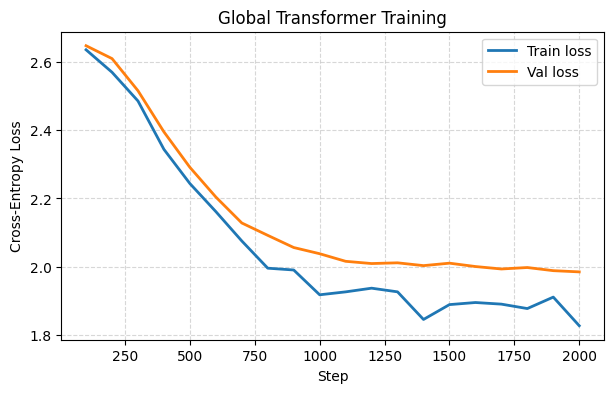

In [80]:
import matplotlib.pyplot as plt

# ---- Plot losses ----
steps = [s for s,_ in train_log]
train_vals = [t for _,t in train_log]
val_vals = [v for _,v in val_log]

plt.figure(figsize=(7,4))
plt.plot(steps, train_vals, label="Train loss", linewidth=2)
plt.plot(steps, val_vals, label="Val loss", linewidth=2)
plt.xlabel("Step"); plt.ylabel("Cross-Entropy Loss")
plt.title("Global Transformer Training")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()